In [98]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
import shap

In [99]:
df = pd.read_csv(
    r"D:\VSCProjects\test-car\cars.csv",
    sep=';',
    encoding='utf-16'
)

In [100]:
df

,brand,currency,description,model,price,url,year,Город,Коробка передач,Кузов,"Объем двигателя, л",Привод,Растаможен,Руль,Цвет,Пробег,Наличие,VIN
0,Mercedes-Benz,₸,"полный электропакет , налог уплачен, техосмот...",GL 550,5800000,https://kolesa.kz/a/show/10235750,2008,Актау,типтроник,внедорожник,5.5 (бензин),полный привод,Да,слева,черный металлик,NaN,NaN,NaN
1,BMW,₸,"тонировка , обогрев зеркал, хрустальная оптик...",X5,5500000,https://kolesa.kz/a/show/10269314,2009,Нур-Султан (Астана),автомат,кроссовер,4.8 (бензин),полный привод,Да,слева,черный,170 км,NaN,NaN
2,Mercedes-Benz,₸,"лонг, состояние нового авто немец газ-бензин п...",S 350,7770000,https://kolesa.kz/a/show/1063798,2006,Алматы,типтроник,седан,3.5 (бензин),NaN,Да,слева,черный,60 000 км,NaN,NaN
3,Mitsubishi,₸,"литые диски, тонировка, люк , хрустальная опт...",Outlander,3200000,https://kolesa.kz/a/show/10695701,2003,Семей,типтроник,кроссовер,2.4 (бензин),полный привод,Да,слева,серебристый металлик,120 000 км,NaN,NaN
4,Ретро-автомобили,₸,"налог уплачен, техосмотр пройден, вложений не ...","ГАЗ 21 ""Волга""",3900000,https://kolesa.kz/a/show/10852142,1970,Алматы,механика,седан,2.4 (бензин),задний привод,Да,слева,черный,1 200 км,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108531,Mercedes-Benz,₸,"люк , ксенон, биксенон, дневные ходовые огни ...",G 500,8000000,https://kolesa.kz/a/show/95800950,1998,Алматы,автомат,внедорожник,5 (бензин),полный привод,Да,слева,черный металлик,NaN,NaN,NaN
108532,Mercedes-Benz,₸,2006 Mercedes-Benz s65amg. Original. Long. V-1...,S 65 AMG,8700000,https://kolesa.kz/a/show/95801019,2006,Алматы,типтроник,седан,6 (бензин),задний привод,Да,слева,белый,112 000 км,NaN,NaN
108533,Mercedes-Benz,₸,"люк, литые диски, ветровики, тонировка , ксен...",GL 550,8400000,https://kolesa.kz/a/show/95801055,2009,Алматы,автомат,внедорожник,5.5 (бензин),полный привод,Да,слева,черный,NaN,NaN,NaN
108534,Toyota,₸,Авто в идеальном состоянии. Кузов полностью в ...,4Runner,8500000,https://kolesa.kz/a/show/95801158,2008,Нур-Султан (Астана),автомат,внедорожник,4 (газ-бензин),полный привод,Да,слева,черный металлик,230 000 км,NaN,NaN


In [101]:
df.description.head()

0    полный электропакет ,  налог уплачен, техосмот...
1    тонировка ,  обогрев зеркал, хрустальная оптик...
2    лонг, состояние нового авто немец газ-бензин п...
3    литые диски, тонировка, люк ,  хрустальная опт...
4    налог уплачен, техосмотр пройден, вложений не ...
Name: description, dtype: str

In [102]:
df.currency.unique()

<StringArray>
['₸']
Length: 1, dtype: str

In [103]:
df.describe()

,price,year
count,1.085360e+05,108536.000000
mean,3.627690e+06,2003.358231
std,5.502069e+06,8.957116
min,5.500000e+02,1913.000000
25%,1.000000e+06,1996.000000
50%,2.000000e+06,2004.000000
75%,4.000000e+06,2011.000000
max,2.600000e+08,2019.000000


In [104]:
df.describe(include='object')

C:\Users\ritac\AppData\Local\Temp\ipykernel_11804\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,brand,currency,description,model,url,Город,Коробка передач,Кузов,"Объем двигателя, л",Привод,Растаможен,Руль,Цвет,Пробег,Наличие,VIN
count,108536,108536,103280,108495,108536,108536,108536,108536,108508,94814,108536,108508,97862,64816,4163,4662
unique,121,1,99630,1633,108536,311,7,15,330,3,2,2,42,9836,1,3945
top,Toyota,₸,Срочно,Camry,https://kolesa.kz/a/show/10235750,Алматы,механика,седан,1.6 (бензин),передний привод,Да,слева,белый,200 000 км,На заказ,77777777*77****77
freq,16646,108536,137,4592,1,24647,53228,51995,16517,50470,95622,99851,16244,1408,4163,138


In [105]:
df.columns

Index(['brand', 'currency', 'description', 'model', 'price', 'url', 'year',
       'Город', 'Коробка передач', 'Кузов', 'Объем двигателя, л', 'Привод',
       'Растаможен', 'Руль', 'Цвет', 'Пробег', 'Наличие', 'VIN'],
      dtype='str')

In [106]:
df[df.description == "Срочно"]

,brand,currency,description,model,price,url,year,Город,Коробка передач,Кузов,"Объем двигателя, л",Привод,Растаможен,Руль,Цвет,Пробег,Наличие,VIN
9115,Lifan,₸,Срочно,Solano,1400000,https://kolesa.kz/a/show/90634278,2011,Аксу,механика,седан,1.6 (бензин),NaN,Да,слева,серебристый металлик,NaN,NaN,NaN
12350,Mercedes-Benz,₸,Срочно,CLS 350,4500000,https://kolesa.kz/a/show/92213458,2007,Павлодар,автомат,седан,3.5 (бензин),задний привод,Да,слева,бордовый металлик,200 000 км,NaN,NaN
15193,ВАЗ (Lada),₸,Срочно,2110 (седан),950000,https://kolesa.kz/a/show/93149141,2007,Актобе,механика,седан,1.5 (газ-бензин),передний привод,Да,слева,серебристый металлик,NaN,NaN,NaN
16033,Toyota,₸,Срочно,Land Cruiser,14800000,https://kolesa.kz/a/show/93366613,2012,Алматы,автомат,внедорожник,3.9 (бензин),полный привод,Да,слева,белый металлик,140 000 км,NaN,NaN
16138,ГАЗ,₸,Срочно,3302 (ГАЗель Бизнес),2900000,https://kolesa.kz/a/show/93393199,2009,Шымкент,механика,фургон,2.9 (газ-бензин),задний привод,Да,слева,белый,325 000 км,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105316,Mercedes-Benz,₸,Срочно,E 230,480000,https://kolesa.kz/a/show/95789552,1991,Шымкент,автомат,седан,2.3 (бензин),NaN,Да,слева,белый металлик,NaN,NaN,NaN
105756,Daewoo,₸,Срочно,Nexia,1100000,https://kolesa.kz/a/show/95790809,2013,Узынагаш,механика,седан,1.5 (бензин),передний привод,Да,слева,серый,NaN,NaN,NaN
106159,Audi,₸,Срочно,80,400000,https://kolesa.kz/a/show/95791901,1989,Нур-Султан (Астана),механика,седан,2.3 (бензин),передний привод,Да,слева,белый,232 323 км,NaN,NaN
106914,Hyundai,₸,Срочно,Starex,1900000,https://kolesa.kz/a/show/95793882,2004,Шымкент,автомат,микроавтобус,2.5 (дизель),NaN,Да,слева,серебристый,NaN,NaN,NaN


# EDA

Переименуем признаки для более корректной работы

In [107]:
df = df.rename(columns={
    "brand": "brand",
    "currency": "currency",
    "description": "description",
    "model": "model",
    "price": "price",
    "url": "url",
    "year": "year",

    "Город": "city",
    "Коробка передач": "transmission",
    "Кузов": "body_type",
    "Объем двигателя, л": "engine_volume",
    "Привод": "drive_type",
    "Растаможен": "custom_cleared",
    "Руль": "steering_wheel",
    "Цвет": "color",
    "Пробег": "mileage",
    "Наличие": "availability",
    "VIN": "vin"
})

In [108]:
df.availability.isnull().sum() / len(df.availability) * 100

np.float64(96.16440627994398)

#  Обоснование удаления признаков
* url — содержит ссылки на объявления, которые недоступны для анализа и не позволяют извлечь структурированные признаки, поэтому удалён как нефункциональный идентификатор.

* vin — уникальный 17-значный идентификатор автомобиля, не содержащий обобщающей информации и приводящий к переобучению, поэтому удалён как нерелевантный признак.

* currency — во всех наблюдениях представлена одна валюта (тенге), признак константный и неинформативный, поэтому удалён.

* availability — содержит около 96% пропусков, не имеет стабильной структуры и не поддаётся надёжному восстановлению, поэтому удалён как слабый и ненадёжный признак.

In [109]:
df = df.drop(columns=["url", "vin", "currency", "description","availability"])

## Примечание по признаку `description`

Признак `description` был исключён из текущей модели, так как представляет собой неструктурированный текст с высокой вариативностью и слабой повторяемостью значений.

Например, значение **"Срочно"** встречается всего 137 раз из 103280 наблюдений, что делает его статистически незначимым.

---

## Причина исключения

- отсутствие единого формата описаний  
- высокая зашумлённость данных  
- невозможность прямого использования в базовой модели без NLP-предобработки  

---

## Потенциал признака

Признак может быть полезен при дальнейшем применении методов NLP (TF-IDF, эмбеддинги, извлечение ключевых фраз).Хотелось бы обсудить с бизнесом структуру и происхождение текстовых описаний для возможной стандартизации данных.

---

## Вывод

На текущем этапе `description` исключён из модели как нерелевантный для табличного ML, но потенциально является ценным источником информации при использовании NLP-подходов.

## Добавлен признак car_age = 2026 - year, так как возраст автомобиля является ключевым фактором амортизации. В отличие от года выпуска, возраст формирует более интерпретируемую и монотонную зависимость с ценой, что улучшит качество модели.

In [110]:
current_year = 2026
df["car_age"] = current_year - df["year"]
df = df.drop(columns=["year"])

In [111]:
df["car_age"].describe()

count    108536.000000
mean         22.641769
std           8.957116
min           7.000000
25%          15.000000
50%          22.000000
75%          30.000000
max         113.000000
Name: car_age, dtype: float64

In [112]:
df[df["car_age"] > 80]

,brand,model,price,city,transmission,body_type,engine_volume,drive_type,custom_cleared,steering_wheel,color,mileage,car_age
458,Ретро-автомобили,Willys,10500000,Алматы,механика,внедорожник,2.2 (бензин),полный привод,Да,слева,зеленый,100 км,83
582,Ретро-автомобили,Willys,23800000,Алматы,механика,внедорожник,2.2 (бензин),NaN,Да,слева,зеленый,18 000 км,82
956,Ретро-автомобили,Другая,19999997,Алматы,автомат,кабриолет,2 (бензин),задний привод,Да,слева,NaN,7 777 км,99
2615,Ретро-автомобили,Willys,5900000,Алматы,механика,кабриолет,2 (бензин),NaN,Да,слева,коричневый,20 000 км,89
2734,Ретро-автомобили,Другая,57000000,Нур-Султан (Астана),механика,седан,2.5 (бензин),NaN,Да,справа,белый,NaN,87
7072,BMW,120,2000000,Петропавловск,механика,купе,2.5 (бензин),задний привод,Да,слева,серебристый,100 км,94
43892,Ретро-автомобили,ГАЗ М-1,1200000,Сарыагаш,механика,седан,1.2 (бензин),NaN,Да,слева,черный,NaN,87
48198,УАЗ,2206,230000,Казыгурт,механика,внедорожник,2.3 (бензин),задний привод,Да,слева,коричневый,7 777 777 км,87
54829,Ретро-автомобили,ГАЗ М-1,20000000,Петропавловск,механика,универсал,3.2 (бензин),NaN,Да,слева,NaN,NaN,86
56563,Ретро-автомобили,ГАЗ 67Б,3000000,Алматы,механика,внедорожник,3.2 (бензин),NaN,Да,слева,зеленый,NaN,82


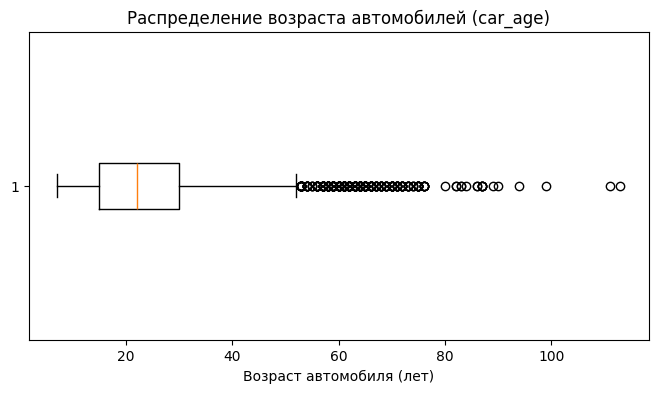

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.boxplot(df["car_age"].dropna(), vert=False)

plt.title("Распределение возраста автомобилей (car_age)")
plt.xlabel("Возраст автомобиля (лет)")

plt.show()

In [114]:
df["mileage"] = (
    df["mileage"]
    .str.replace("км", "", regex=False)
    .str.replace(" ", "", regex=False)
)

df["mileage"] = pd.to_numeric(df["mileage"], errors="coerce")

# EDA

## Проверка гипотез

В рамках исследования были сформулированы три гипотезы о факторах амортизации автомобилей:

1. Амортизация зависит от возраста автомобиля  
2. Амортизация зависит от бренда  
3. Амортизация зависит от пробега  



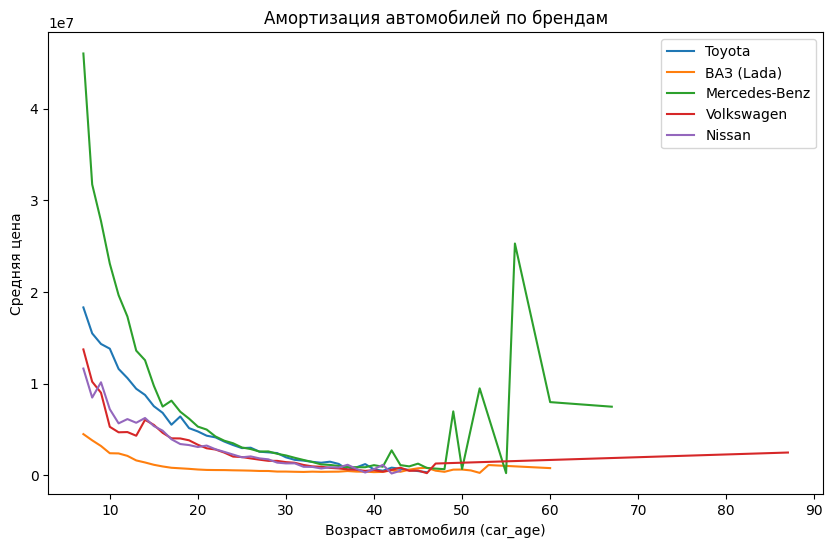

In [115]:
import matplotlib.pyplot as plt

# берем топ брендов (чтобы не было шума)
top_brands = df["brand"].value_counts().head(5).index

plt.figure(figsize=(10,6))

for brand in top_brands:
    temp = df[df["brand"] == brand]
    
    grouped = temp.groupby("car_age")["price"].mean()
    
    plt.plot(grouped.index, grouped.values, label=brand)

plt.xlabel("Возраст автомобиля (car_age)")
plt.ylabel("Средняя цена")
plt.title("Амортизация автомобилей по брендам")
plt.legend()
plt.show()

# Анализ зависимости цены от бренда авто

---

### 1. Общая тенденция (все бренды)

- Экспоненциальное снижение цены в первые 10-20 лет  
- Наибольшее падение происходит в первые 5–10 лет  
- После ~30–40 лет наблюдается стабилизация стоимости на низком уровне  

---

### 2. Различия по брендам

| Бренд | Начальная цена | Амортизация | Особенности |
|---|---|---|---|
| Mercedes-Benz | ~45 млн | высокая | возможный рост у классических авто |
| Toyota | ~18 млн | высокая | стабильное снижение |
| Volkswagen | ~13 млн | средняя | аномалии у старых авто |
| Nissan | ~12 млн | высокая | поведение близко к Toyota |
| ВАЗ (Lada) | ~4 млн | низкая | медленная амортизация |

---

### 3. Этапы амортизации

**0–10 лет (быстрое падение)**  
- Основная потеря стоимости (до ~70–80%)

**10–30 лет (замедление)**  
- Сближение цен между брендами  
- Диапазон стабилизируется (≈1–3 млн)

**30+ лет (стабилизация / аномалии)**  
- Большинство авто: минимальная стоимость  
- Возможны коллекционные выбросы

---

### 4. Аномалии

- **Mercedes-Benz (старые модели)**: рост стоимости из-за коллекционной ценности  
- **Volkswagen**: рост у ретро-моделей (например, классические модели)  
- Возможны шумы из-за малой выборки старых автомобилей  




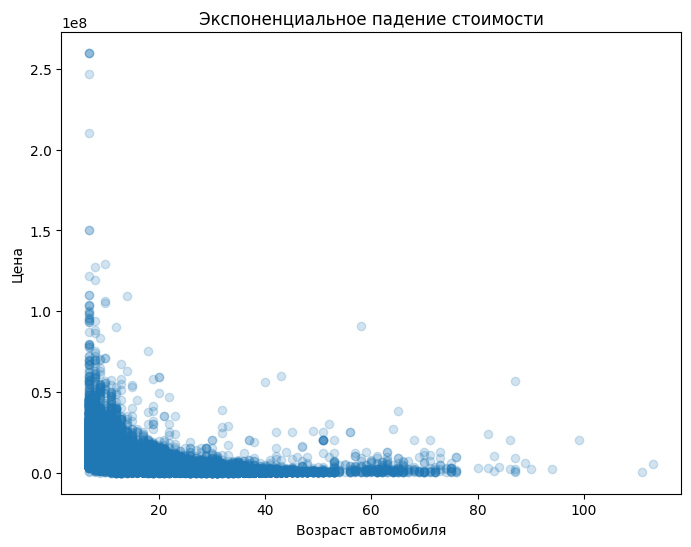

In [116]:
import numpy as np
import matplotlib.pyplot as plt

temp = df.copy()

temp = temp[temp["price"] > 0]

plt.figure(figsize=(8,6))

plt.scatter(temp["car_age"], temp["price"], alpha=0.2)

plt.xlabel("Возраст автомобиля")
plt.ylabel("Цена")
plt.title("Экспоненциальное падение стоимости")

plt.show()

## Анализ зависимости цены от возраста: экспоненциальное падение стоимости

График показывает зависимость цены автомобиля от возраста на уровне отдельных наблюдений и подтверждает нелинейный характер амортизации.

---

### 1. Подтверждение гипотезы

Гипотеза подтверждается: зависимость цены от возраста имеет экспоненциальный характер.

- 0–10 лет: резкое падение стоимости (основная амортизация)
- 10–40 лет: постепенное снижение и стабилизация
- 40+ лет: выход на плато с редкими выбросами вверх (коллекционные авто)

---

### 2. Ключевые наблюдения

#### Гетероскедастичность
- Молодые автомобили (0–15 лет): высокий разброс цен (от бюджетных до премиальных моделей)
- Старые автомобили (30+ лет): низкая вариативность, большинство объектов имеют низкую стоимость  
- Исключения: редкие коллекционные автомобили с высокой ценой

---

#### Плотность данных
- Основная масса наблюдений сосредоточена в диапазоне 0–15 лет  
- После 40 лет количество наблюдений резко уменьшается  
- Это отражает структуру рынка: старые автомобили представлены реже  

---

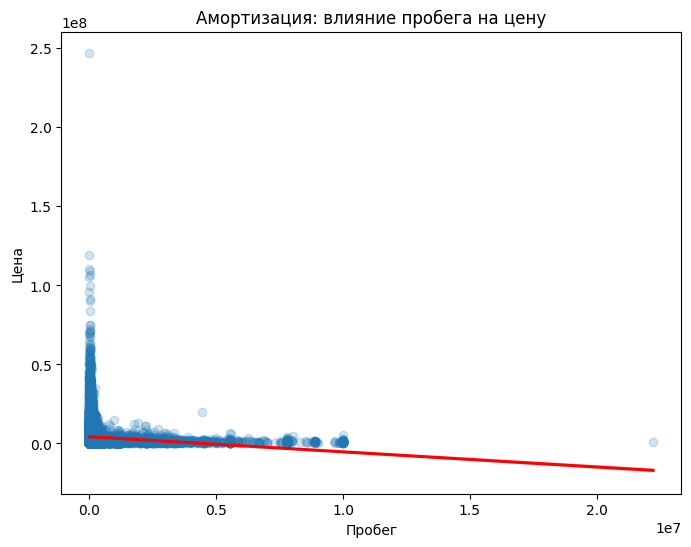

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="mileage",
    y="price",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)

plt.title("Амортизация: влияние пробега на цену")
plt.xlabel("Пробег")
plt.ylabel("Цена")

plt.show()

##  Анализ зависимости цены от пробега

---

### 1. Слабая зависимость

Наблюдается очень слабая отрицательная зависимость между пробегом и ценой.

- Линия тренда почти горизонтальная  
- Пробег оказывает значительно меньшее влияние, чем возраст автомобиля  

---

### 2. Высокая дисперсия при малом пробеге

- При низком пробеге цена варьируется от минимальных значений до ~250 млн  
- Пробег не отражает ключевые факторы стоимости:
  - возраст автомобиля  
  - бренд и класс  
  - техническое состояние  
- Влияние пробега сильно “перекрывается” другими признаками  

---

### 3. Выбросы

- Экстремальные значения:
  - высокая цена при минимальном пробеге (элитные авто)  
  - аномально большой пробег у части автомобилей (коммерческое использование)  
- Основная масса данных сосредоточена в зоне низкий пробег / средняя цена  

---

### 4. Нелинейность эффекта

- После определённого уровня пробега влияние на цену практически исчезает  
- Дальнейшее увеличение пробега не приводит к заметному изменению стоимости  

---

##  Вывод

Пробег оказывает ограниченное влияние на стоимость автомобиля и существенно уступает возрасту по предсказательной силе. Его эффект частично перекрывается другими признаками, что объясняет его низкую значимость в модели.

# Предобработка

In [118]:
raw = df["engine_volume"]

df["engine_volume"] = raw.str.extract(r"(\d+\.?\d*)").astype(float)
df["fuel_type"] = raw.str.extract(r"\((.*?)\)")

In [119]:
df[["engine_volume","fuel_type"]]

,engine_volume,fuel_type
0,5.5,бензин
1,4.8,бензин
2,3.5,бензин
3,2.4,бензин
4,2.4,бензин
...,...,...
108531,5.0,бензин
108532,6.0,бензин
108533,5.5,бензин
108534,4.0,газ-бензин


In [120]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['price'])
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [121]:
eng_map = (
    X_train.dropna(subset=["engine_volume"])
    .groupby(["brand", "model"])["engine_volume"]
    .median()
)

eng_brand_map = (
    X_train.dropna(subset=["engine_volume"])
    .groupby("brand")["engine_volume"]
    .median()
)

global_eng = X_train["engine_volume"].median()

In [122]:
def fill_engine(df, eng_map, eng_brand_map, global_eng):
    df = df.copy()

    # 1 уровень: brand + model
    df["engine_volume"] = df.apply(
        lambda r: eng_map.get((r["brand"], r["model"]))
        if pd.isna(r["engine_volume"]) else r["engine_volume"],
        axis=1
    )

    # 2 уровень: brand
    df["engine_volume"] = df.apply(
        lambda r: eng_brand_map.get(r["brand"])
        if pd.isna(r["engine_volume"]) else r["engine_volume"],
        axis=1
    )

    # 3 уровень: global fallback
    df["engine_volume"] = df["engine_volume"].fillna(global_eng)

    return df

In [123]:
fuel_map = (
    X_train.dropna(subset=["fuel_type"])
    .groupby(["brand", "model"])["fuel_type"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

fuel_brand_map = (
    X_train.dropna(subset=["fuel_type"])
    .groupby("brand")["fuel_type"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

global_fuel = X_train["fuel_type"].mode()[0]

In [124]:
def fill_fuel(df, fuel_map, fuel_brand_map, global_fuel):
    df = df.copy()

    # 1 уровень: brand + model
    df["fuel_type"] = df.apply(
        lambda r: fuel_map.get((r["brand"], r["model"]))
        if pd.isna(r["fuel_type"]) else r["fuel_type"],
        axis=1
    )

    # 2 уровень: brand
    df["fuel_type"] = df.apply(
        lambda r: fuel_brand_map.get(r["brand"])
        if pd.isna(r["fuel_type"]) else r["fuel_type"],
        axis=1
    )

    # 3 уровень: global fallback
    df["fuel_type"] = df["fuel_type"].fillna(global_fuel)

    return df

In [125]:
train_mileage_median = X_train["mileage"].median()

X_train["mileage"] = X_train["mileage"].fillna(train_mileage_median)

In [126]:
X_test["mileage"] = X_test["mileage"].fillna(train_mileage_median)

In [127]:
train_color_median = X_train["color"].mode()[0]

X_train["color"] = X_train["color"].fillna(train_color_median)

In [128]:
X_test["color"] = X_test["color"].fillna(train_color_median)

In [129]:
drive_map = (
    X_train.dropna(subset=["drive_type"])
    .groupby(["brand", "model"])["drive_type"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
drive_brand_map = (
    X_train.dropna(subset=["drive_type"])
    .groupby("brand")["drive_type"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
global_drive = X_train["drive_type"].mode()[0]

In [130]:
def fill_drive_type(df, drive_map, drive_brand_map, global_drive):
    df = df.copy()

    # 1 уровень: brand + model
    df["drive_type"] = df.apply(
        lambda r: drive_map.get((r["brand"], r["model"]))
        if pd.isna(r["drive_type"]) else r["drive_type"],
        axis=1
    )

    # 2 уровень: brand
    df["drive_type"] = df.apply(
        lambda r: drive_brand_map.get(r["brand"])
        if pd.isna(r["drive_type"]) else r["drive_type"],
        axis=1
    )

    # 3 уровень: global
    df["drive_type"] = df["drive_type"].fillna(global_drive)

    return df

In [131]:
model_map = (
    X_train.dropna(subset=["model"])
    .groupby("brand")["model"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
global_model = X_train["model"].mode()[0]
drive_brand_map = (
    X_train.dropna(subset=["drive_type"])
    .groupby("brand")["drive_type"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
global_drive = X_train["drive_type"].mode()[0]

In [132]:
def fill_model(df, model_map, global_model):
    df = df.copy()

    # 1 уровень: brand → model
    df["model"] = df["model"].fillna(
        df["brand"].map(model_map)
    )

    # 2 уровень: global fallback
    df["model"] = df["model"].fillna(global_model)

    return df

In [133]:
X_train = fill_engine(X_train, eng_map, eng_brand_map, global_eng)
X_test = fill_engine(X_test, eng_map, eng_brand_map, global_eng)

X_train = fill_fuel(X_train, fuel_map, fuel_brand_map, global_fuel)
X_test = fill_fuel(X_test, fuel_map, fuel_brand_map, global_fuel)

X_train = fill_drive_type(X_train, drive_map, drive_brand_map, global_drive)
X_test = fill_drive_type(X_test, drive_map, drive_brand_map, global_drive)

X_train = fill_model(X_train, model_map, global_model)
X_test = fill_model(X_test, model_map, global_model)

In [134]:
X_train.columns

Index(['brand', 'model', 'city', 'transmission', 'body_type', 'engine_volume',
       'drive_type', 'custom_cleared', 'steering_wheel', 'color', 'mileage',
       'car_age', 'fuel_type'],
      dtype='str')

In [135]:
scaler_cols = ['engine_volume','mileage','car_age']
str_col = ['brand', 'model', 'city', 'transmission', 'body_type',
       'drive_type', 'custom_cleared', 'steering_wheel', 'color', 'fuel_type']

In [154]:
from scipy.sparse import hstack

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[scaler_cols])
X_test_scaled = scaler.transform(X_test[scaler_cols])

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=True
)

X_train_ohe = ohe.fit_transform(X_train[str_col])
X_test_ohe = ohe.transform(X_test[str_col])

X_train_lr = hstack([X_train_scaled, X_train_ohe])
X_test_lr = hstack([X_test_scaled, X_test_ohe])

# В качестве моделей были выбраны : Линейная регрессия и Catboost

In [155]:
print(X_train_ohe.shape)

(86828, 2058)


In [156]:
print(X_test_ohe.shape)

(21708, 2058)


In [157]:
lr_model = LinearRegression()

lr_model.fit(X_train_lr, y_train)


lr_pred = lr_model.predict(X_test_lr)

In [158]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression
MAE: 1311241.103360726
RMSE: 3093235.1690808614
R2: 0.7086459829079073


In [159]:
cat_features = [
    'brand',
    'model',
    'city',
    'transmission',
    'body_type',
    'drive_type',
    'custom_cleared',
    'steering_wheel',
    'color',
    'fuel_type'
]

X_train[cat_features] = (
    X_train[cat_features]
    .fillna("unknown")
    .astype(str)
)

X_test[cat_features] = (
    X_test[cat_features]
    .fillna("unknown")
    .astype(str)
)

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=42,
    verbose=100
)


In [160]:

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)


0:	learn: 5080464.6317226	test: 5352835.7834789	best: 5352835.7834789 (0)	total: 132ms	remaining: 1m 5s
100:	learn: 1527152.0951490	test: 2166764.5137235	best: 2166764.5137235 (100)	total: 11.9s	remaining: 47s
200:	learn: 1282921.2130108	test: 2024872.3264450	best: 2024872.3264450 (200)	total: 23.3s	remaining: 34.6s
300:	learn: 1147488.1840421	test: 1965204.3082022	best: 1965204.3082022 (300)	total: 34.8s	remaining: 23s
400:	learn: 1069905.9201792	test: 1937248.3064248	best: 1937241.3184675 (399)	total: 46.2s	remaining: 11.4s
499:	learn: 1004414.5341949	test: 1913204.9841683	best: 1913204.9841683 (499)	total: 58s	remaining: 0us

bestTest = 1913204.984
bestIteration = 499



CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=500, learning_rate=0.1, loss_function='RMSE', random_state=42, verbose=100)

In [161]:
cat_pred = cat_model.predict(X_test)


cat_mae = mean_absolute_error(y_test, cat_pred)

cat_rmse = np.sqrt(mean_squared_error(y_test, cat_pred))

cat_r2 = r2_score(y_test, cat_pred)

print("\nCatBoost")
print("MAE:", cat_mae)
print("RMSE:", cat_rmse)
print("R2:", cat_r2)


CatBoost
MAE: 605761.4317617529
RMSE: 1913204.9842020443
R2: 0.888540230923162


# Сравнение моделей

| Модель | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 1.31 млн | 3.09 млн | 0.708 |
| CatBoost | 0.606 млн | 1.91 млн | 0.889 |

---

# Интерпретация метрик

## R² (коэффициент детерминации)

Метрика R² показывает, какую долю изменчивости цены автомобиля способна объяснить модель.

### Linear Regression
Для линейной регрессии значение:

$$
R^2 = 0.708
$$

Это означает, что модель объясняет примерно 71% дисперсии стоимости автомобилей. Для простой линейной модели на реальных рыночных данных это является удовлетворительным результатом.

Однако линейная регрессия плохо справляется со сложными нелинейными зависимостями между признаками и ценой автомобиля.

### CatBoost
Для модели CatBoost:

$$
R^2 = 0.889
$$

Модель объясняет почти 89% дисперсии стоимости автомобилей, что является очень высоким результатом для задачи прогнозирования цен.

Это свидетельствует о том, что CatBoost значительно лучше улавливает закономерности рынка автомобилей.

---

## MAE (Mean Absolute Error)

MAE показывает среднюю абсолютную ошибку предсказания модели.

### Linear Regression

$$
MAE \approx 1.31 \text{ млн тенге}
$$

### CatBoost

$$
MAE \approx 606 \text{ тыс. тенге}
$$

Это означает, что предсказание модели CatBoost в среднем отличается от реальной стоимости автомобиля примерно на 600 тысяч тенге.

С учетом того, что:

- медианная стоимость автомобиля составляет около 2 млн тенге;
- средняя стоимость автомобиля составляет около 3.6 млн тенге;

ошибка модели составляет примерно 16% от средней цены автомобиля, что является хорошим результатом для рынка подержанных автомобилей.

---

## RMSE (Root Mean Squared Error)

RMSE показывает среднеквадратичную ошибку модели и сильнее штрафует большие ошибки предсказания.

### Linear Regression

$$
RMSE \approx 3.09 \text{ млн тенге}
$$

### CatBoost

$$
RMSE \approx 1.91 \text{ млн тенге}
$$

Значение RMSE заметно выше MAE, поскольку в датасете присутствуют:

- выбросы;
- редкие автомобили;
- автомобили премиального сегмента;
- очень дорогие модели.

Максимальная стоимость автомобиля в выборке достигает:

$$
260 \text{ млн тенге}
$$

Поэтому наличие отдельных крупных ошибок является ожидаемым.

---

# Общий вывод по моделям

В рамках исследования были протестированы две модели машинного обучения:

- линейная регрессия;
- градиентный бустинг CatBoost.

Линейная регрессия показала удовлетворительное качество и может использоваться как базовая baseline-модель. Однако из-за линейной природы алгоритма модель не смогла эффективно описать сложные зависимости между характеристиками автомобиля и его стоимостью.

Модель CatBoost продемонстрировала значительно лучшие результаты по всем используемым метрикам:

- более высокий коэффициент детерминации;
- меньшую среднюю ошибку предсказания;
- более устойчивую работу на сложных данных.

Преимущество CatBoost связано со способностью:

- учитывать нелинейные зависимости;
- автоматически обрабатывать категориальные признаки;
- моделировать сложные взаимодействия между признаками.

Таким образом, модель CatBoost была выбрана в качестве основной модели для прогнозирования стоимости автомобилей.

In [162]:
explainer = shap.TreeExplainer(cat_model)

In [163]:
X_sample = X_test.sample(2000, random_state=42)

shap_values = explainer.shap_values(X_sample)

## SHAP-анализ признаков

---

### car_age (возраст автомобиля)

- Высокий возраст автомобиля оказывает отрицательное влияние на предсказанную цену  
- Низкий возраст автомобиля оказывает положительное влияние на предсказанную цену  

**Вывод:**  
Новые автомобили значительно дороже, что соответствует рыночной логике.

---

### engine_volume (объём двигателя)

- Большой объём двигателя увеличивает предсказанную стоимость автомобиля  
- Малый объём двигателя снижает предсказанную стоимость автомобиля  

**Вывод:**  
Автомобили с более мощными двигателями имеют более высокую рыночную стоимость.

---

### mileage (пробег)

- Высокий пробег оказывает слабое отрицательное влияние на цену  
- Низкий пробег оказывает слабое положительное влияние на цену  
- Общая важность признака относительно невысока и может пересекаться с влиянием возраста автомобиля  

**Вывод:**  
Пробег влияет на стоимость автомобиля слабее, чем возраст, что может быть связано с их взаимной корреляцией.

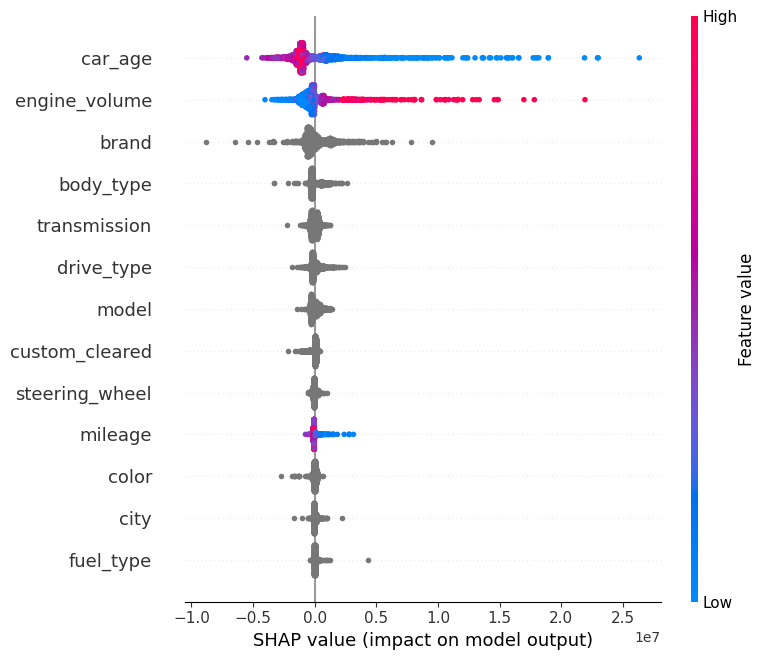

In [164]:
shap.summary_plot(shap_values, X_sample)

## График важности признаков (SHAP bar plot)

---

### Топ-3 наиболее важных признака

**car_age (возраст автомобиля) ~ 1.8 × 10⁶**  
- Безусловный лидер по влиянию на цену  
- В ~2 раза важнее второго признака  
- Основной фактор амортизации стоимости автомобиля  

---

**engine_volume (объём двигателя) ~ 1.0 × 10⁶**  
- Второй по значимости технический параметр  
- Существенно влияет на формирование цены  
- Отражает мощность и класс автомобиля  

---

**brand (бренд) ~ 0.65 × 10⁶**  
- Марка автомобиля существенно влияет на стоимость  
- Определяет премиальность и сегмент рынка  

---

### Признаки средней важности

- body_type  
- transmission  
- drive_type  
- model  

(в диапазоне ~0.25 – 0.45 × 10⁶)

- Эти признаки отражают конструктивные и рыночные особенности автомобиля  
- Влияют на цену, но слабее ключевых факторов (возраст, двигатель, бренд)

---

### Низкая важность признаков

- fuel_type  
- city  
- color  
- steering_wheel  
- mileage  

(< 0.15 × 10⁶)

- Слабое влияние на итоговую цену  
- Частично объясняется корреляцией с более сильными признаками (например, возрастом и брендом)  
- Цвет и тип топлива практически не являются ценообразующими факторами в данной выборке

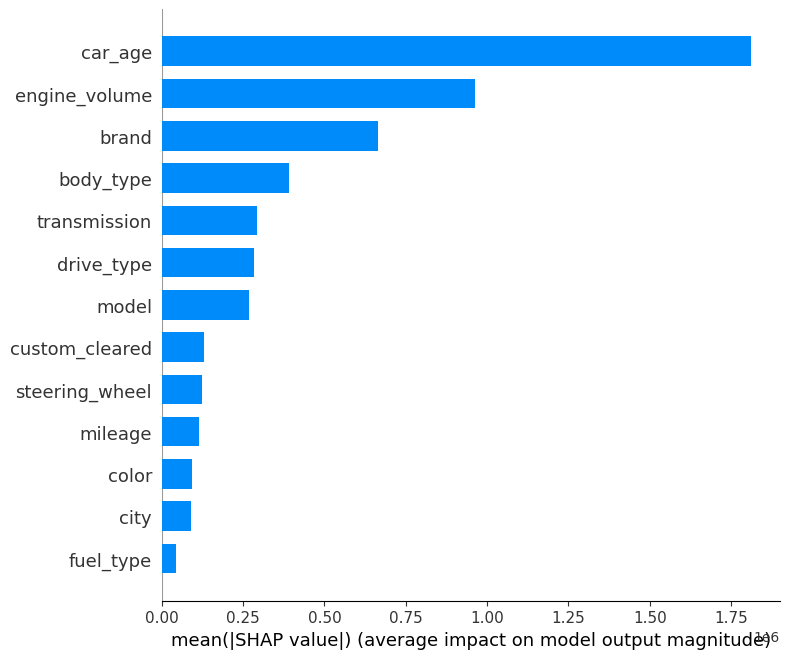

In [165]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

## Выводы об амортизации автомобилей

На основе анализа данных и результатов модели CatBoost можно сделать следующие выводы о характере амортизации автомобилей:

---

### 1. Возраст автомобиля — главный фактор потери стоимости

Возраст автомобиля является ключевым драйвером снижения цены и оказывает наибольшее влияние среди всех признаков.

- С увеличением возраста стоимость автомобиля существенно снижается  
- Новые автомобили имеют значительно более высокую рыночную стоимость  
- Влияние возраста носит нелинейный характер: наибольшая потеря стоимости происходит в первые годы эксплуатации  

---

### 2. Амортизация зависит от технических характеристик

Объём двигателя и класс автомобиля влияют на скорость обесценивания:

- Автомобили с большим объёмом двигателя и более мощными характеристиками сохраняют стоимость лучше  
- Более дешёвые и малолитражные автомобили быстрее теряют цену  
- Технические параметры формируют разную кривую амортизации для разных сегментов рынка  

---

### 3. Бренд влияет на остаточную стоимость

Марка автомобиля существенно влияет на остаточную стоимость:

- Премиальные бренды демонстрируют более медленную амортизацию  
- Массовые бренды теряют стоимость быстрее  
- Таким образом, амортизация зависит не только от возраста, но и от позиционирования бренда  

---

### 4. Пробег имеет вторичное влияние

Пробег оказывает влияние на стоимость, однако оно слабее, чем влияние возраста:

- Частично объясняется высокой корреляцией между пробегом и возрастом  
- В некоторых случаях пробег уточняет степень износа автомобиля внутри одного возрастного сегмента  

---

### 5. Нелинейный характер амортизации

Анализ модели показывает, что:

- амортизация не является линейной функцией времени  
- снижение стоимости зависит от сочетания факторов (возраст, бренд, двигатель, модель)  
- различные сегменты автомобилей имеют разные траектории потери стоимости  

---

### Итог

Амортизация автомобилей в рассматриваемых данных определяется прежде всего возрастом, однако её скорость и форма существенно зависят от бренда и технических характеристик. 

Анализ модели CatBoost и SHAP-значений подтвердил все три гипотезы, однако с различной степенью влияния. Наиболее значимым фактором оказался возраст автомобиля, далее следует бренд, тогда как пробег оказывает вторичное влияние и частично коррелирует с возрастом.

Таким образом, структура амортизации является нелинейной и определяется комбинацией нескольких факторов.